In [ ]:
!pip install ultralytics -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 18.6 MB/s eta 0:00:00a 0:00:01


In [ ]:
import os
import yaml
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
DATA_PATH = "/kaggle/input/datasets/mohsin3333/face-theft-nonvoi-voilence/FYP Dataset 3"

train_images = DATA_PATH + "/train/images"
train_labels = DATA_PATH + "/train/labels"

val_images   = DATA_PATH + "/valid/images"
val_labels   = DATA_PATH + "/valid/labels"

print("train_images:", train_images)
print("train_labels:", train_labels)

train_images: /kaggle/input/datasets/mohsin3333/face-theft-nonvoi-voilence/FYP Dataset 3/train/images
train_labels: /kaggle/input/datasets/mohsin3333/face-theft-nonvoi-voilence/FYP Dataset 3/train/labels


In [ ]:
def clean_data(images_path, labels_path):
    images = os.listdir(images_path)
    removed = 0

    for img in images:
        label = img.replace(".jpg",".txt").replace(".png",".txt")
        label_path = os.path.join(labels_path, label)

        if not os.path.exists(label_path):
            removed += 1

    print(f"Found {removed} images without labels ")

In [ ]:
clean_data(train_images, train_labels)
clean_data(val_images, val_labels)

Found 0 images without labels 
Found 0 images without labels 


In [ ]:
import yaml

data_yaml = {
    "path": DATA_PATH,
    "train": "train/images",
    "val": "valid/images",
    "test": "test/images",
    "names": ['face', 'Theft',  'non_violence', 'violence'],
    "nc": 4
}


with open("/kaggle/working/data.yaml", "w") as f:
    yaml.dump(data_yaml, f)

print("data.yaml created ")

data.yaml created 


In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8m.pt")

In [ ]:
model.train(
    data="/kaggle/working/data.yaml",
    epochs=50,
    imgsz=640,
    batch=16,
    workers=2,
    augment=True
)


Ultralytics 8.4.51 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, pers

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x797d53786b10>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0

In [ ]:
from IPython.display import FileLink

FileLink('/kaggle/working/runs/detect/train/weights/best.pt')

/kaggle/working/runs/detect/train/weights/best.pt

### Load the model

In [ ]:
model_path = "/kaggle/input/models/akramhatem/fighting-model/other/default/1/best Fighting.pt"
model = YOLO(model_path)

In [ ]:
model.val(
    data='/kaggle/working/data.yaml',
    imgsz=640,
    batch=16,
    conf=0.25,
    plots=True
)

Ultralytics 8.4.53 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 93 layers, 25,842,076 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.4±0.4 ms, read: 11.0±2.1 MB/s, size: 36.2 KB)
val: Scanning /kaggle/input/datasets/mohsin3333/face-theft-nonvoi-voilence/FYP Dataset 3/valid/labels... 787 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 787/787 388.2it/s 2.0s0.1s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/mohsin3333/face-theft-nonvoi-voilence/FYP Dataset 3/valid is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 50/50 2.4it/s 21.1s0.4ss
                   all        787       1382      0.936      0.931      0.924      0.748
                  face         37         49      0.979      0.959      0.953      0.745
                 Theft        238        238      0.962      0.958      0.947       0.82
          non_violen

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7f6faa9bd640>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0

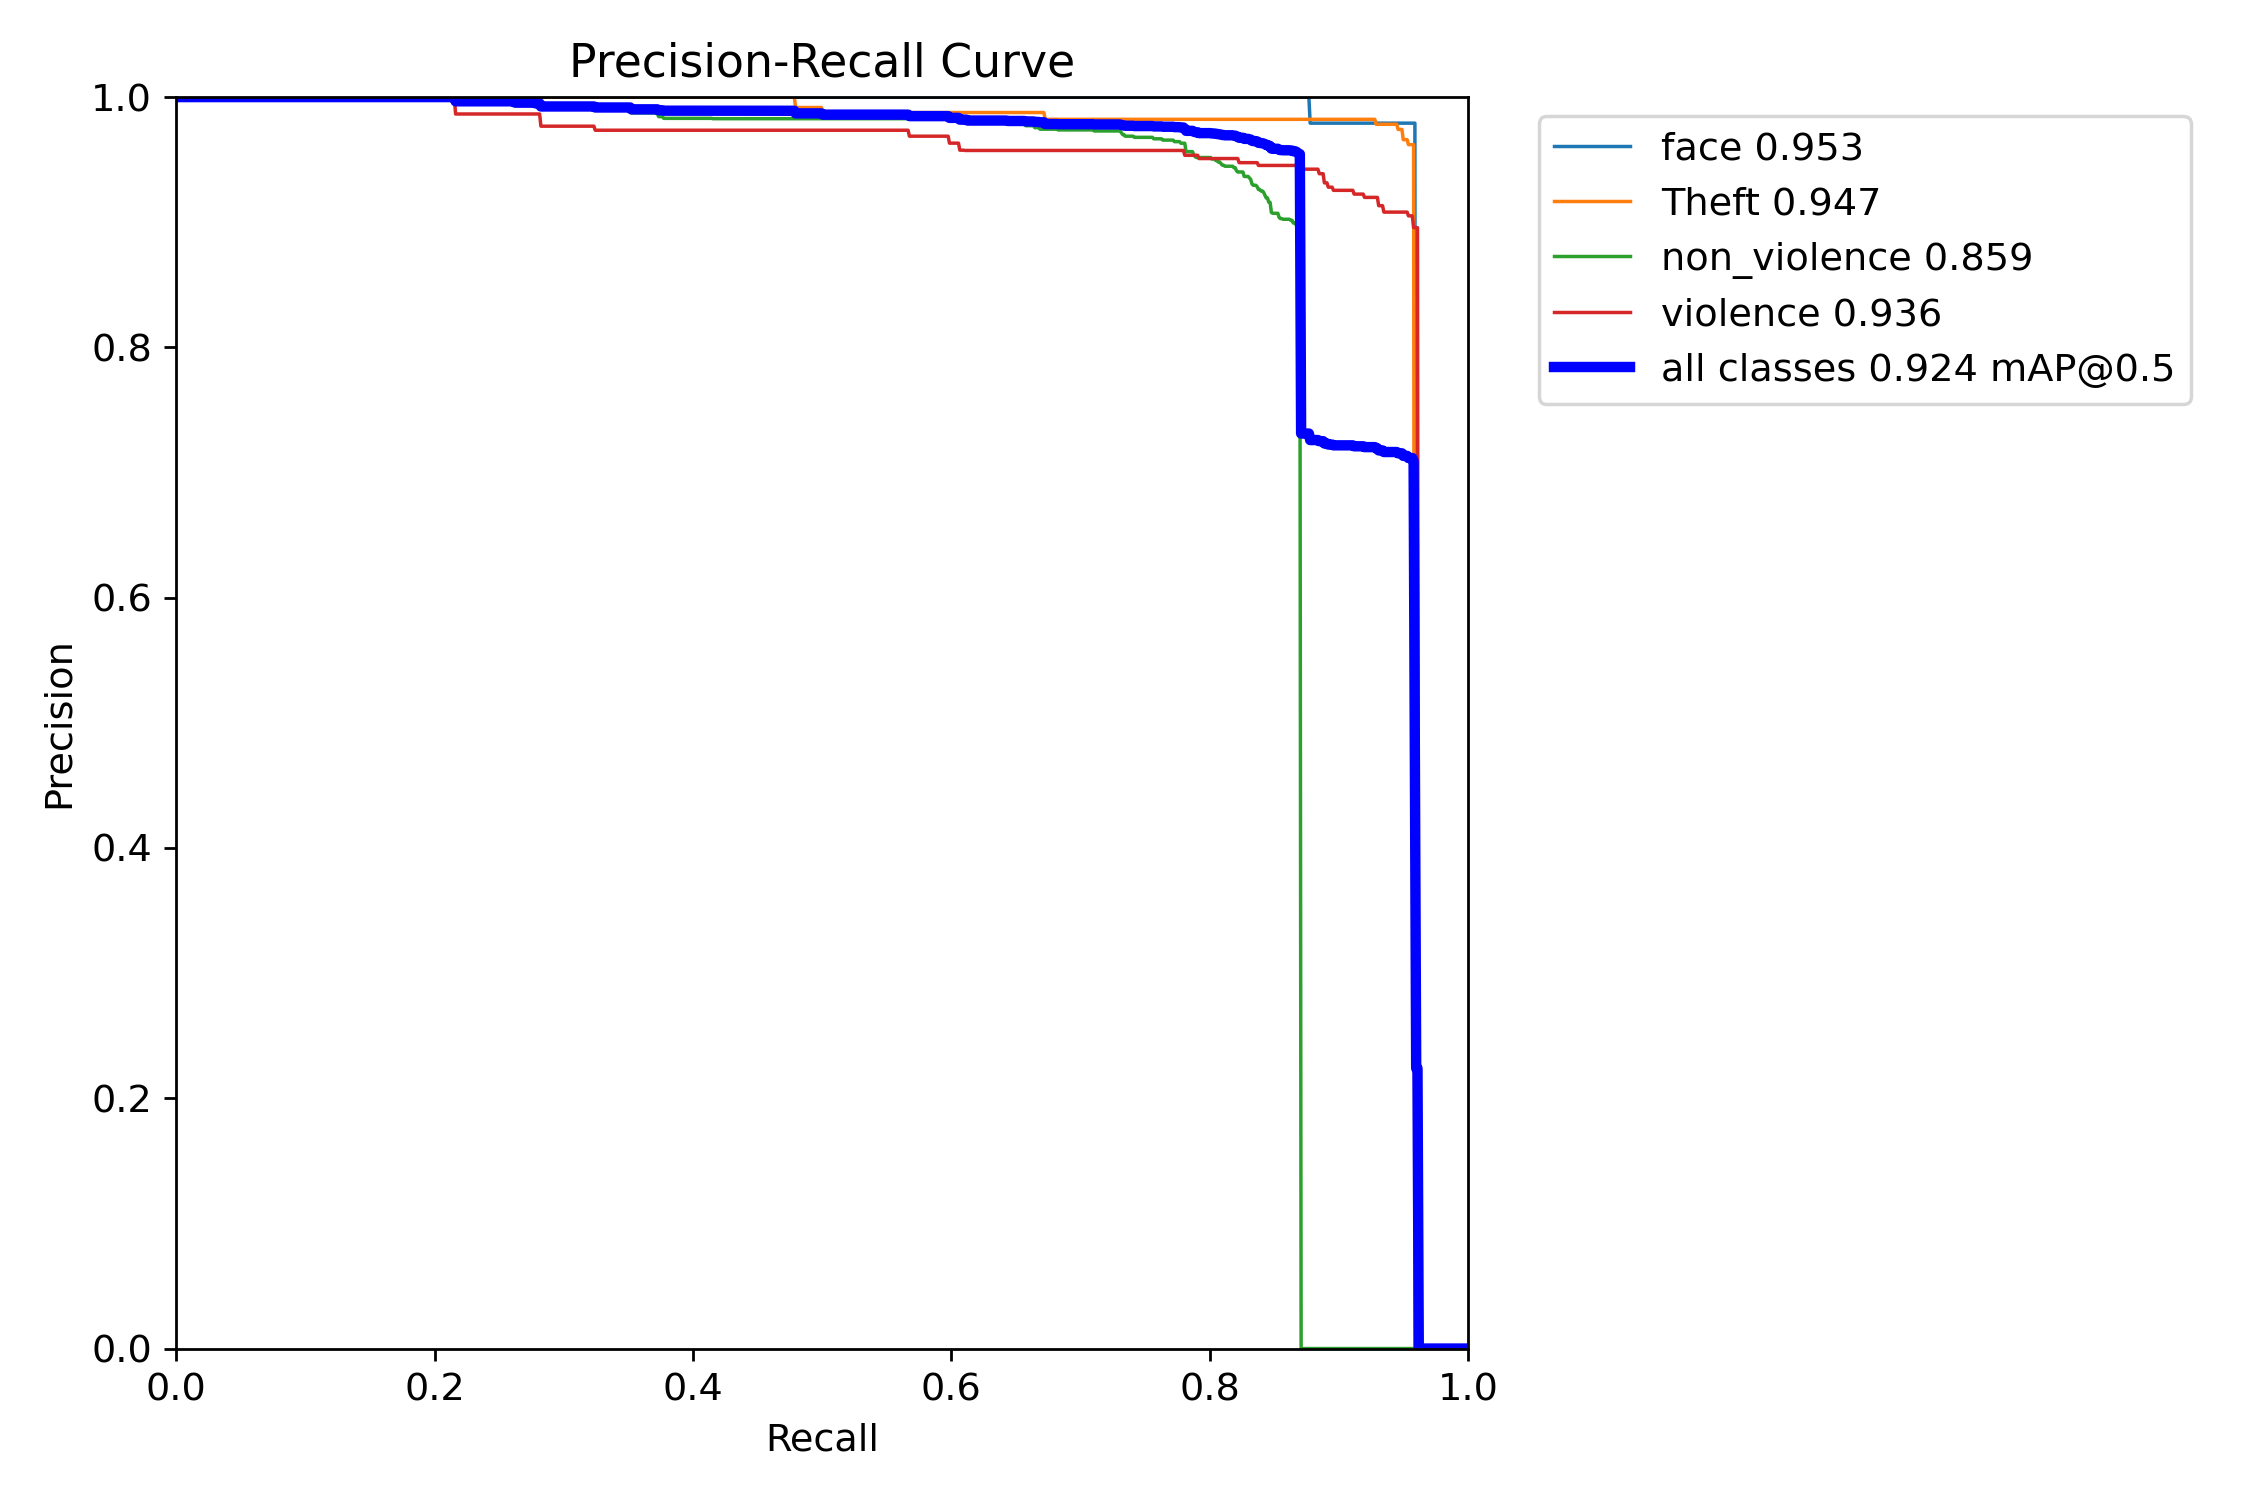

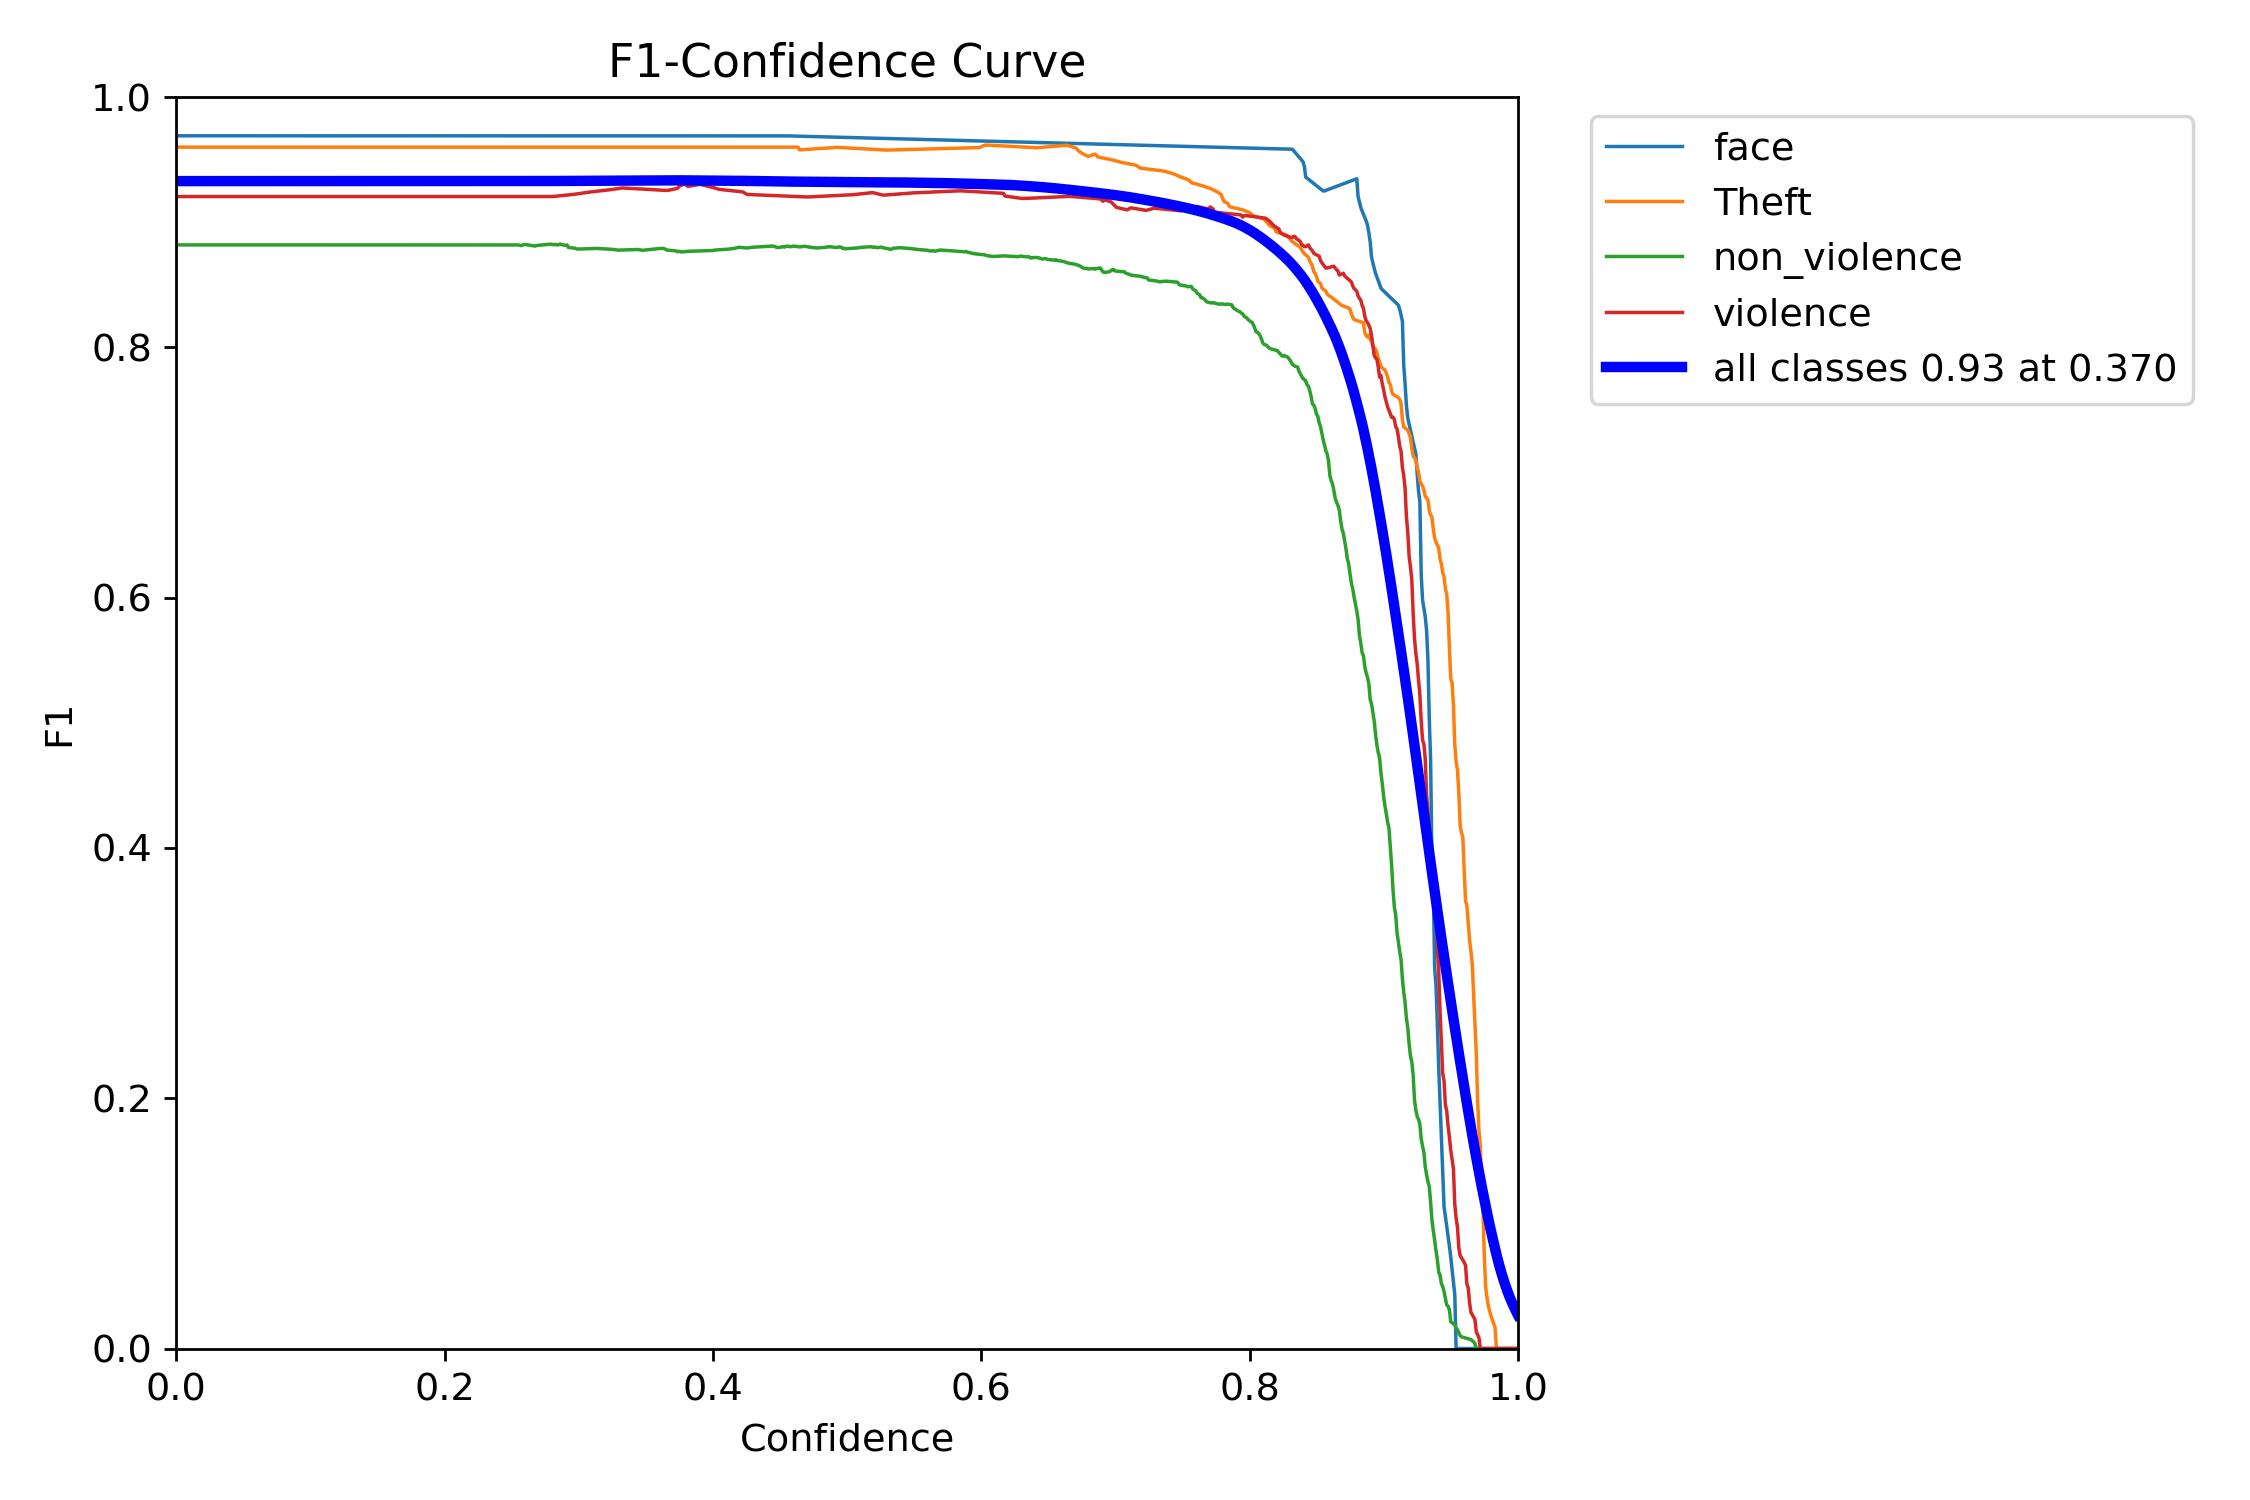

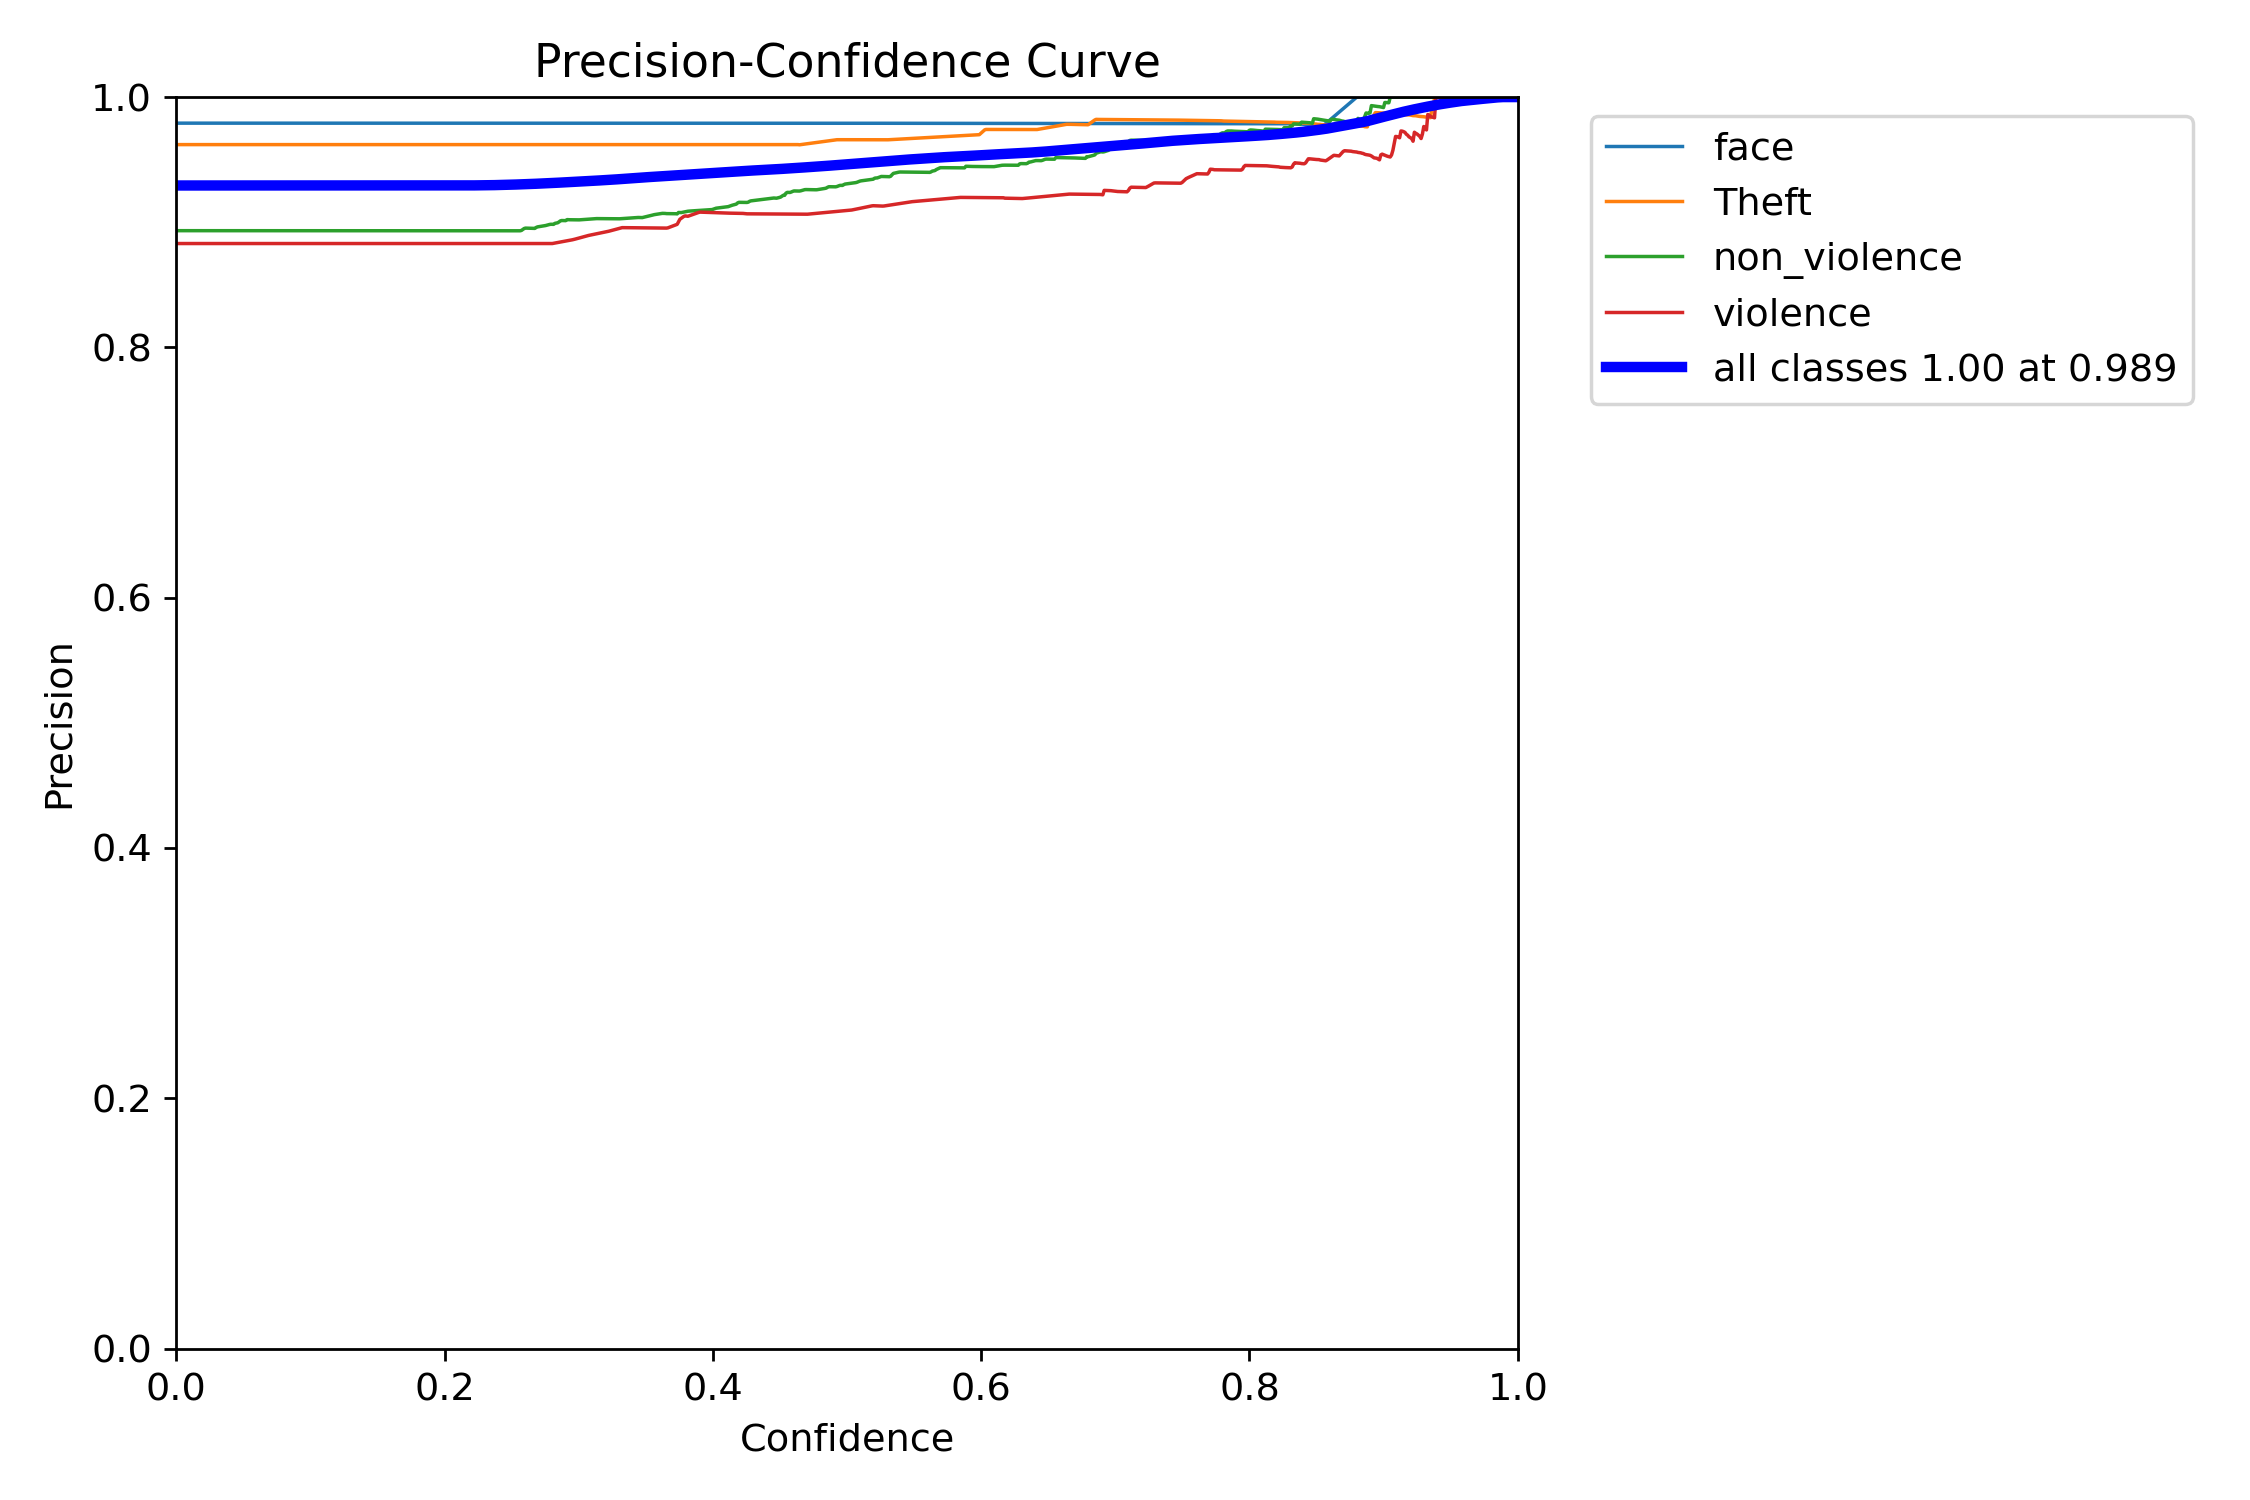

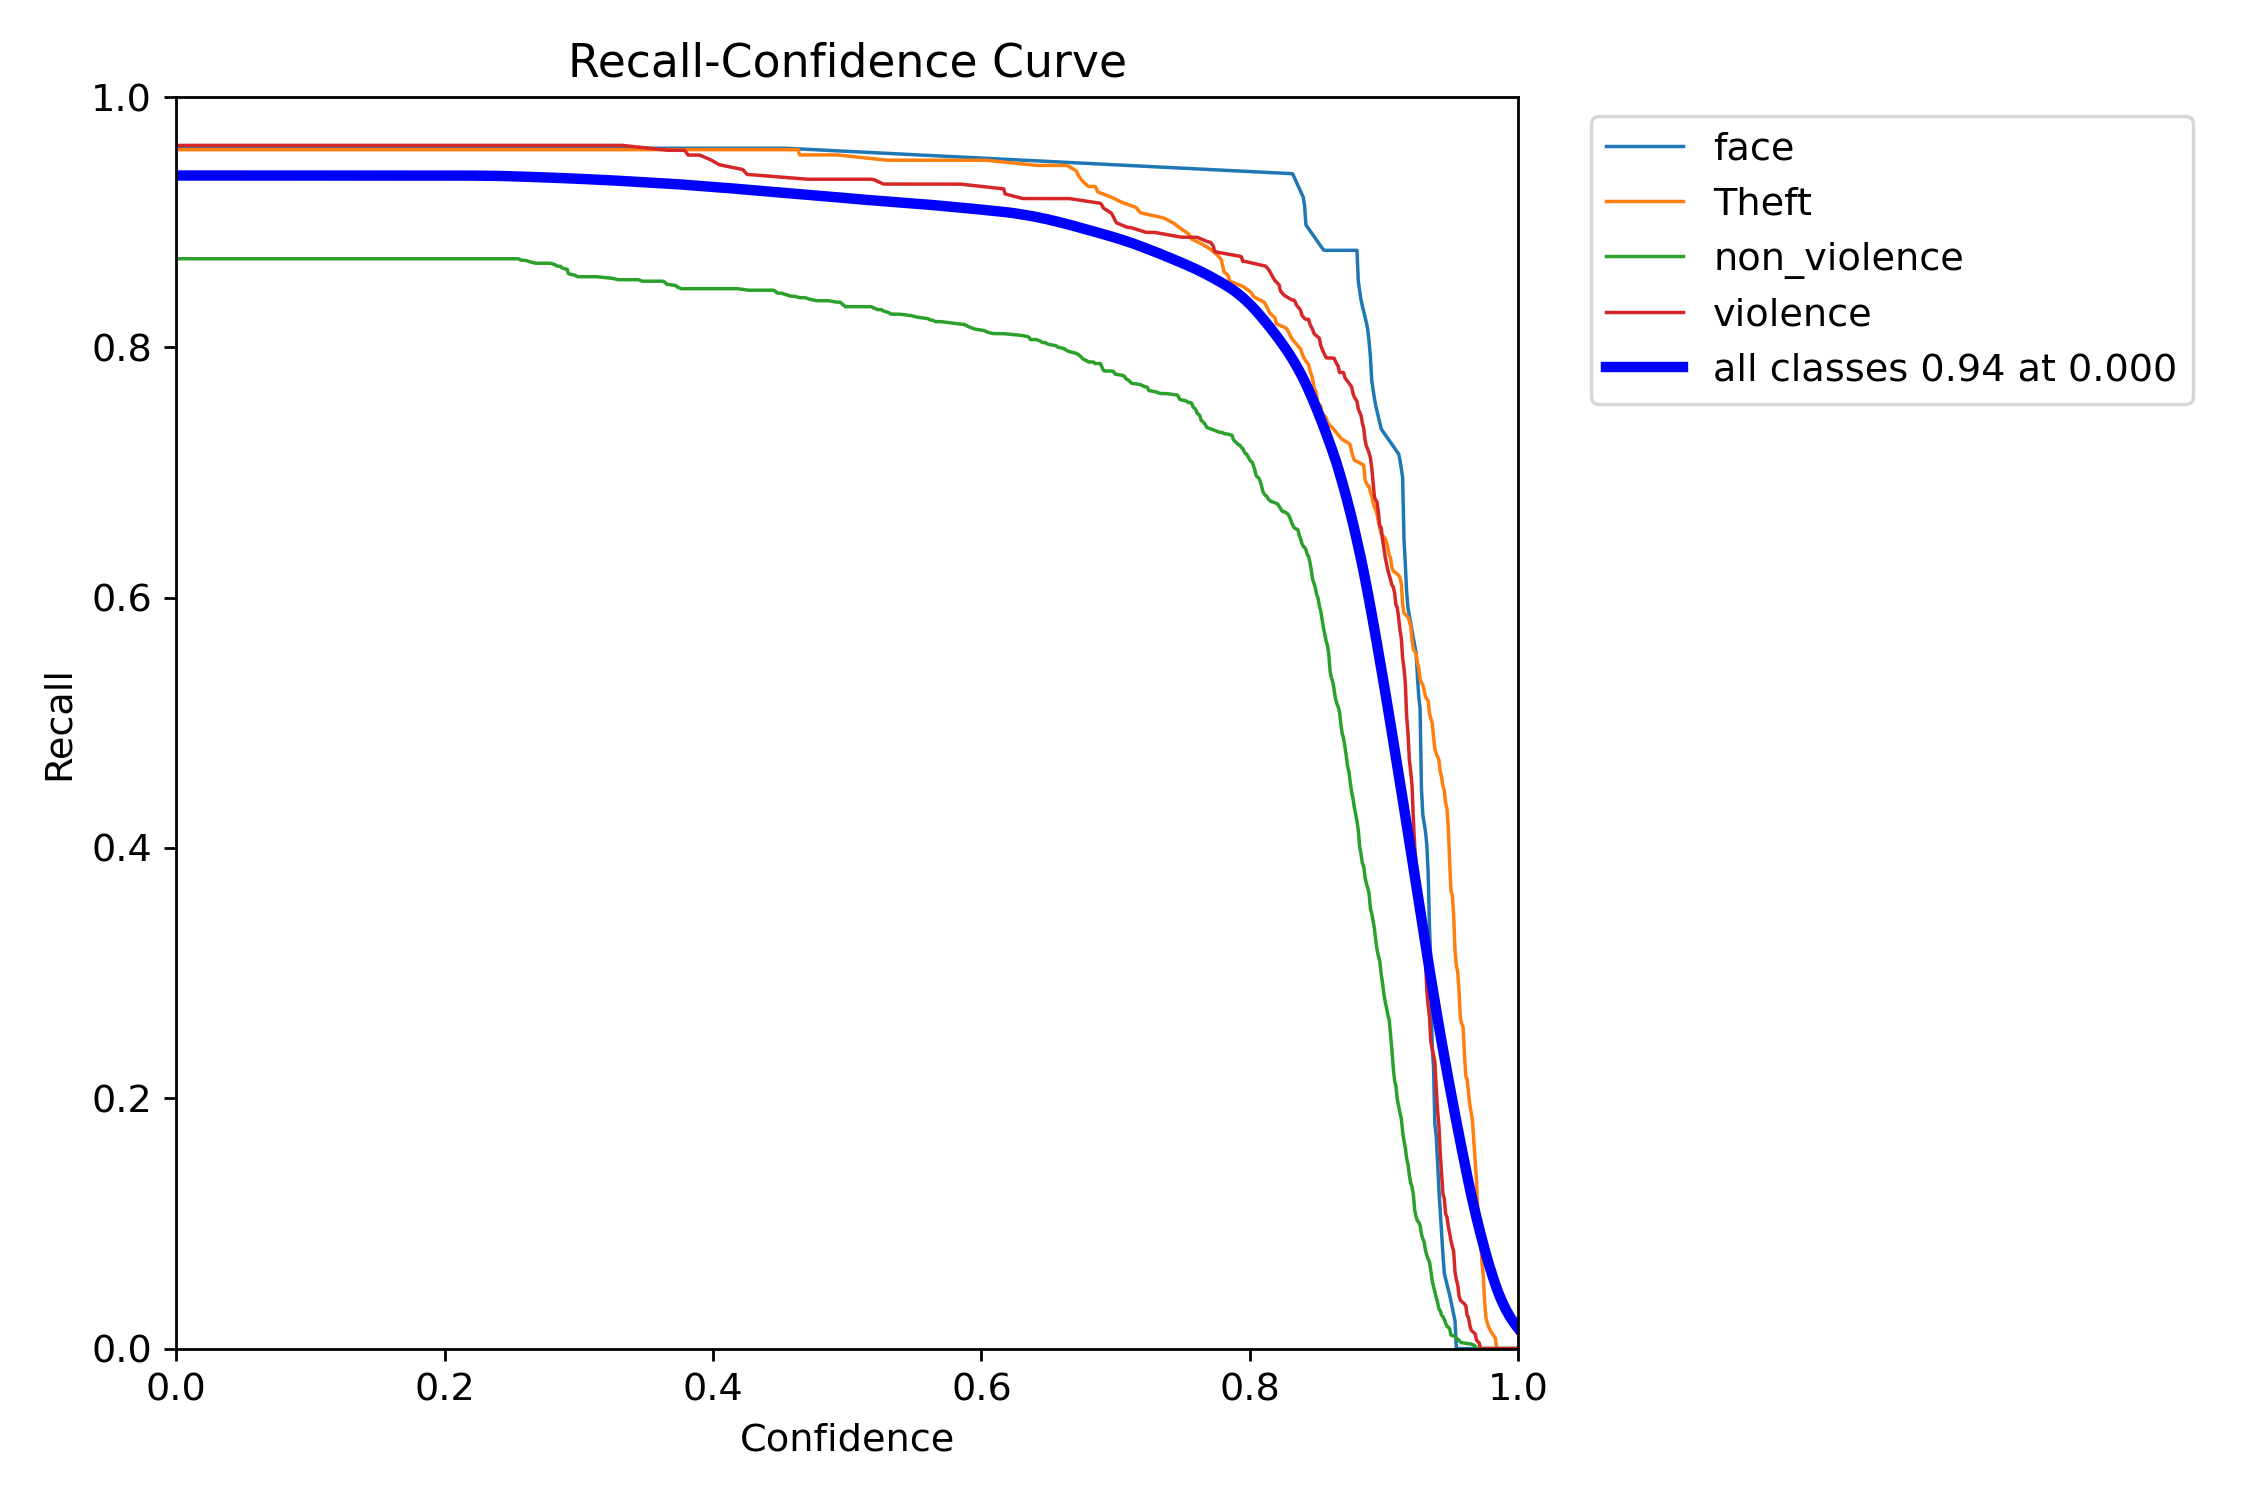

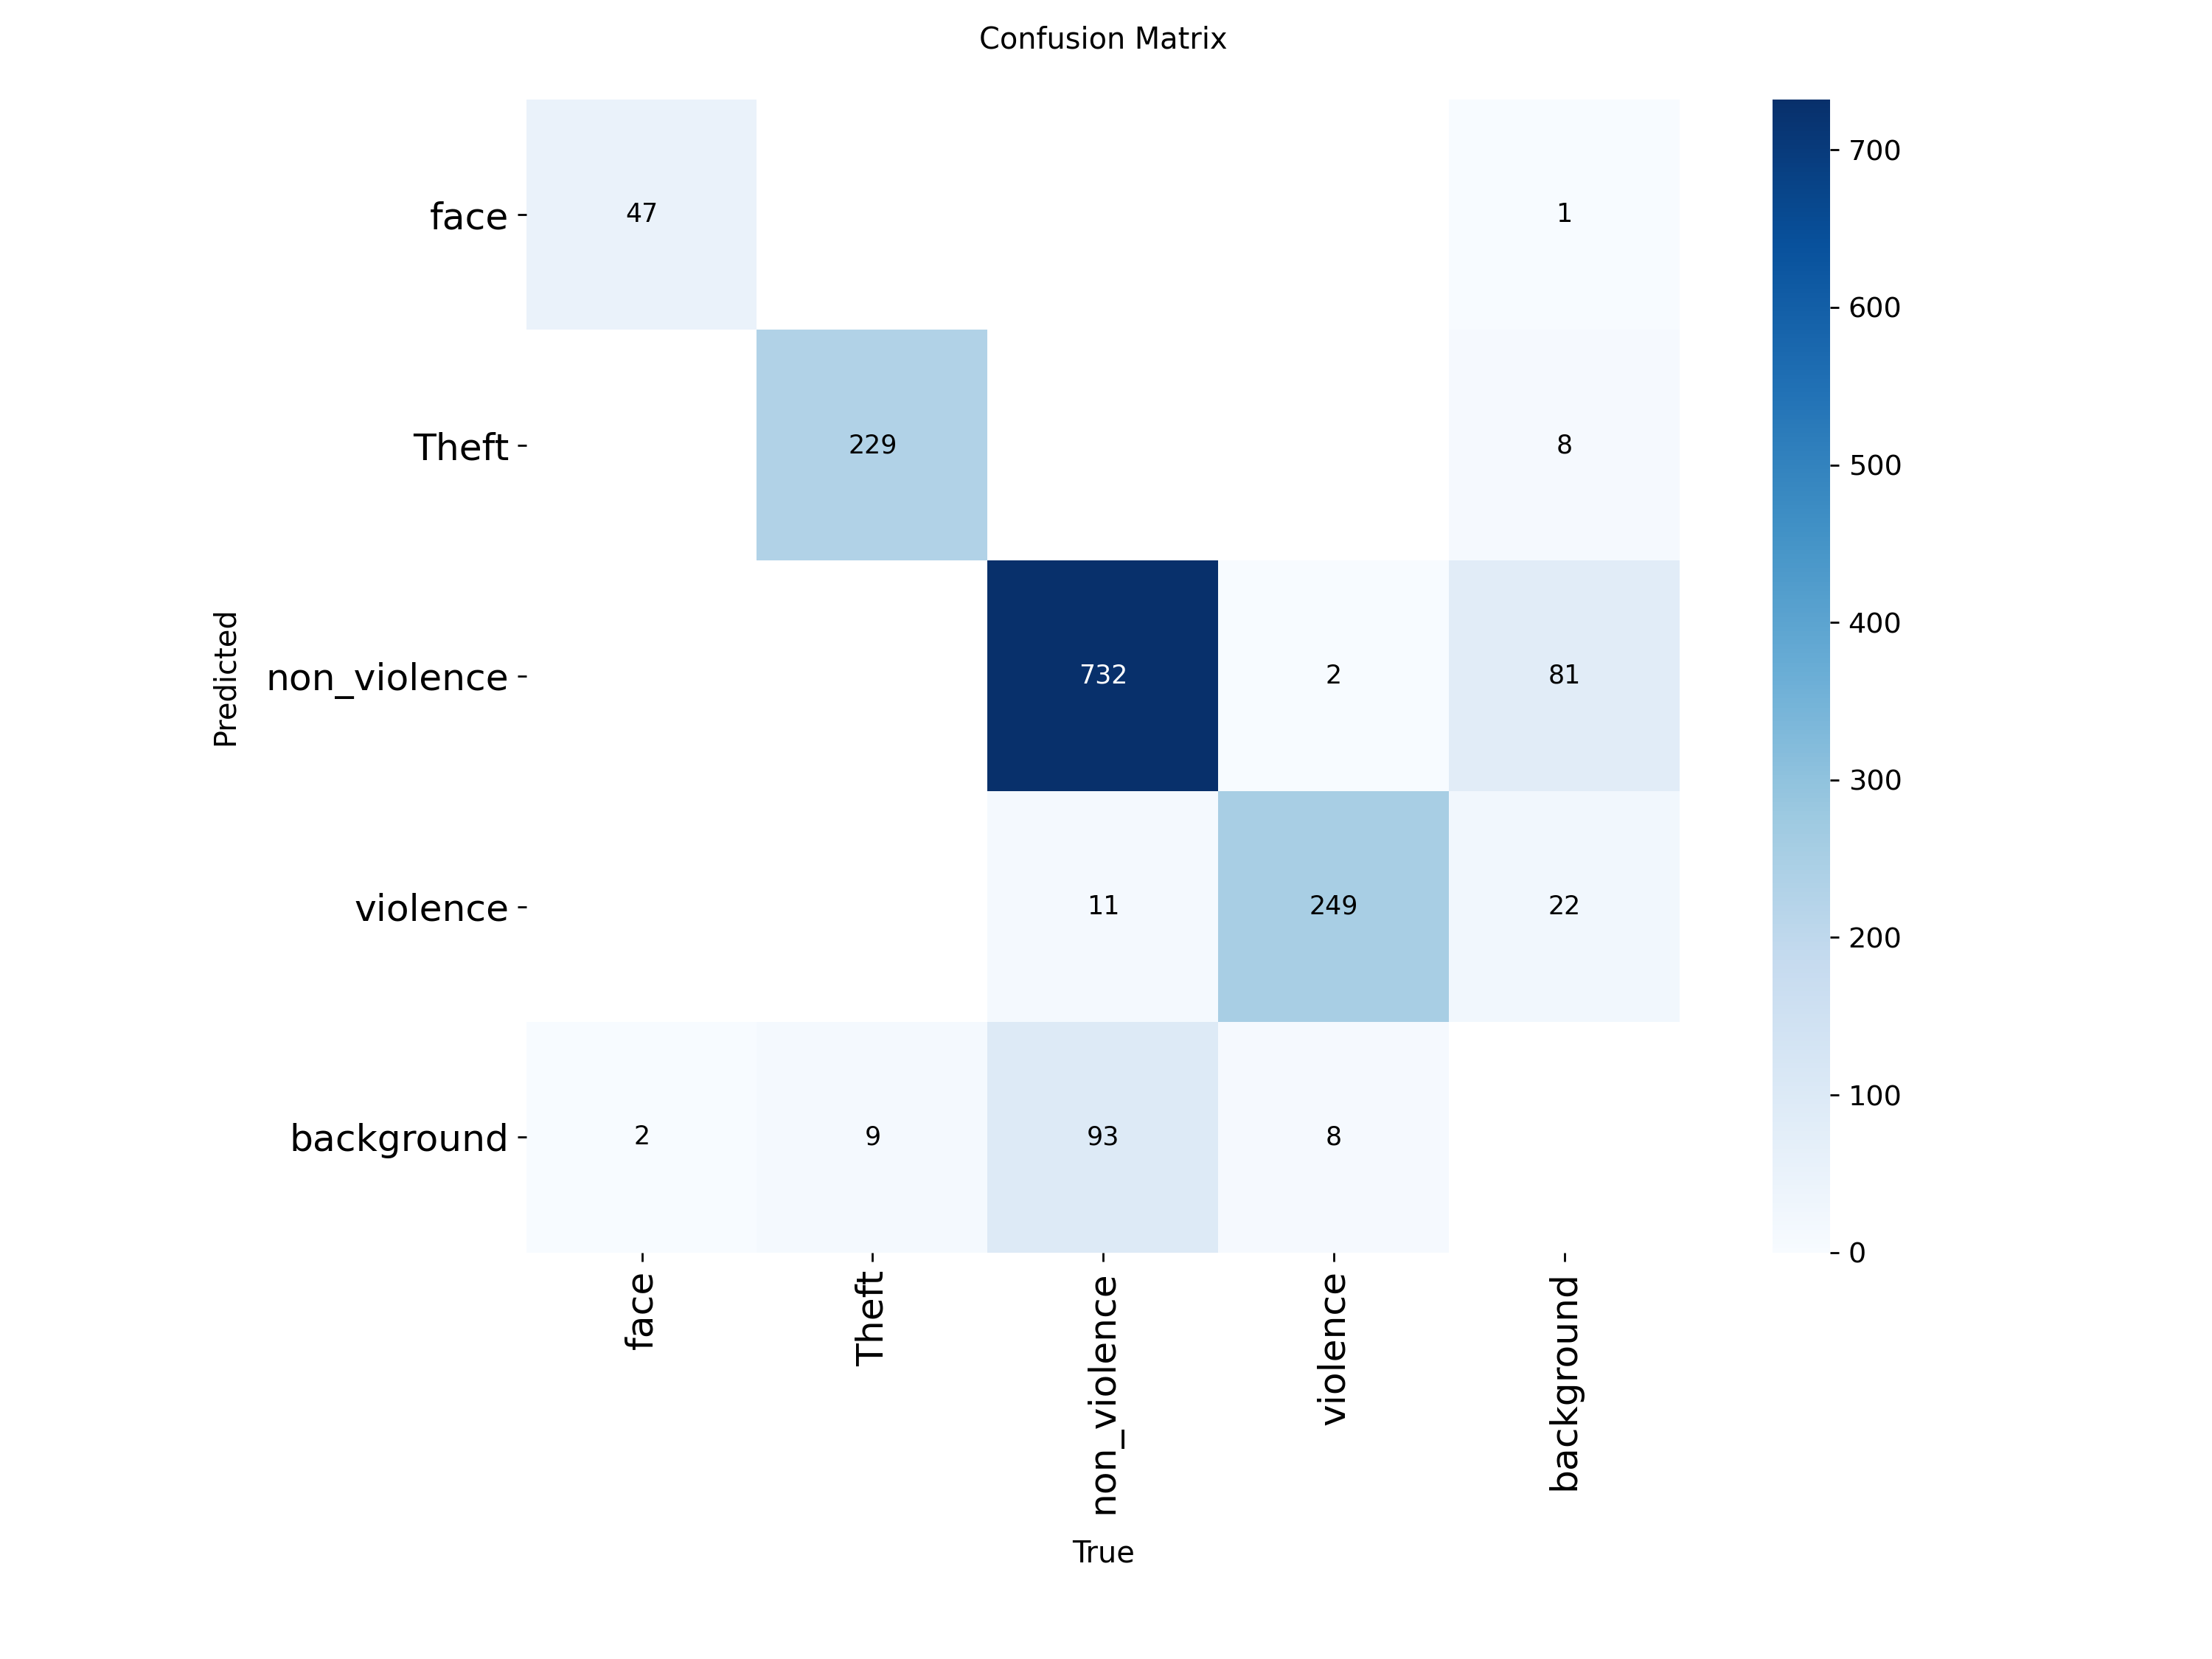

In [ ]:
from IPython.display import Image, display

display(Image('/kaggle/working/runs/detect/val/BoxPR_curve.png'))
display(Image('/kaggle/working/runs/detect/val/BoxF1_curve.png'))
display(Image('/kaggle/working/runs/detect/val/BoxP_curve.png'))
display(Image('/kaggle/working/runs/detect/val/BoxR_curve.png'))
display(Image('/kaggle/working/runs/detect/val/confusion_matrix.png'))


WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

image 1/1471 /kaggle/input/datasets/mohsin3333/face-theft-nonvoi-voilence/FYP Dataset 3/test/images/-I1-MS09uaqsLdGTFkgnS0Rcg1mmPyAj95ySg_eckoM_jpeg_jpg.rf.ca3d216ca28be32265e365299a0af4b6.jpg: 640x640 3 faces, 37.0ms
image 2/1471 /kaggle/input/datasets/mohsin3333/face-theft-nonvoi-voilence/FYP Dataset 3/test/images/0ad90195-cd77-489e-bf85-08c83b80d3e0_jpg.rf.3317b17670bf4318a3b12a9805730774.jpg: 640x640 5 faces, 36.9ms
image 3/1471 /kaggle/input/dataset

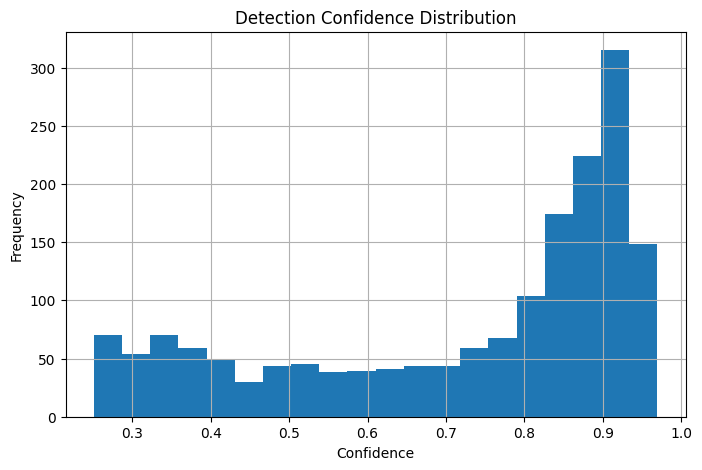

In [ ]:
from ultralytics import YOLO
import matplotlib.pyplot as plt

results = model.predict(
    source='/kaggle/input/datasets/mohsin3333/face-theft-nonvoi-voilence/FYP Dataset 3/test/images',
    conf=0.25,
    save=False
)

confidences = []

for r in results:
    for box in r.boxes:
        confidences.append(float(box.conf))

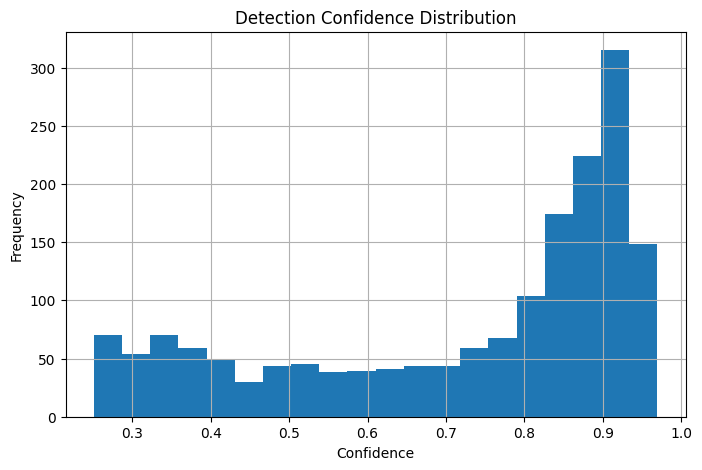

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(confidences, bins=20)
plt.xlabel("Confidence")
plt.ylabel("Frequency")
plt.title("Detection Confidence Distribution")
plt.grid(True)
plt.show()

In [ ]:
model.val(
    data="/kaggle/working/data.yaml",
    split="test"
)

Ultralytics 8.4.52 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 7.5±4.3 MB/s, size: 45.8 KB)
val: Scanning /kaggle/input/datasets/mohsin3333/face-theft-nonvoi-voilence/FYP Dataset 3/test/labels... 1471 images, 28 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1471/1471 202.3it/s 7.3s0.1s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/mohsin3333/face-theft-nonvoi-voilence/FYP Dataset 3/test is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 92/92 2.5it/s 36.6s0.4ss
                   all       1471       1973      0.787      0.684      0.729       0.53
                  face        136        263      0.925      0.892       0.94      0.662
                 Theft        866        868      0.643     0.0657      0.182     0.0526
          non_violence        234        432      0.781      0.887      0.888      0.712
            

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x79f9d9f128d0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0

Selected Image: /kaggle/input/datasets/mohsin3333/face-theft-nonvoi-voilence/FYP Dataset 3/test/images/V_373_F117_jpg.rf.aba5fae59bd3906a04cd99bcef513e44.jpg

image 1/1 /kaggle/input/datasets/mohsin3333/face-theft-nonvoi-voilence/FYP Dataset 3/test/images/V_373_F117_jpg.rf.aba5fae59bd3906a04cd99bcef513e44.jpg: 640x640 4 non_violences, 2 violences, 36.9ms
Speed: 2.5ms preprocess, 36.9ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /kaggle/working/runs/detect/predict


(np.float64(-0.5), np.float64(639.5), np.float64(639.5), np.float64(-0.5))

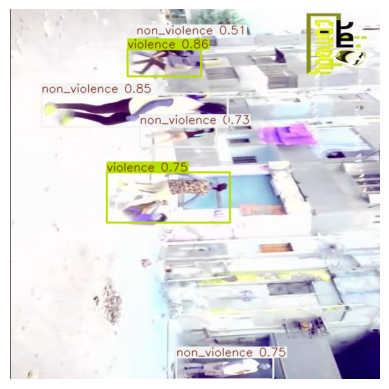

In [ ]:
import os
import random

test_path = "/kaggle/input/datasets/mohsin3333/face-theft-nonvoi-voilence/FYP Dataset 3/test/images"

images = os.listdir(test_path)
random_img = random.choice(images)
img_path = os.path.join(test_path, random_img)

print("Selected Image:", img_path)

results = model.predict(
    source=img_path,
    conf=0.25,
    save=True
)

img = results[0].plot()

from matplotlib import pyplot as plt
plt.imshow(img)
plt.axis("off")